<a href="https://colab.research.google.com/github/Madhuanabala/deepak-bhaiya/blob/classification-models/randomforest__ttop10%2C20%2C30_adasyn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== Top 10 Features ===
Accuracy: 0.5893
AUC: 0.7762
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.55      0.69       238
           1       0.24      0.81      0.37        42

    accuracy                           0.59       280
   macro avg       0.59      0.68      0.53       280
weighted avg       0.84      0.59      0.65       280


=== Top 20 Features ===
Accuracy: 0.8000
AUC: 0.8860
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.81      0.87       238
           1       0.41      0.76      0.53        42

    accuracy                           0.80       280
   macro avg       0.68      0.78      0.70       280
weighted avg       0.87      0.80      0.82       280


=== Top 30 Features ===
Accuracy: 0.7893
AUC: 0.8692
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.81      0.87       238
      

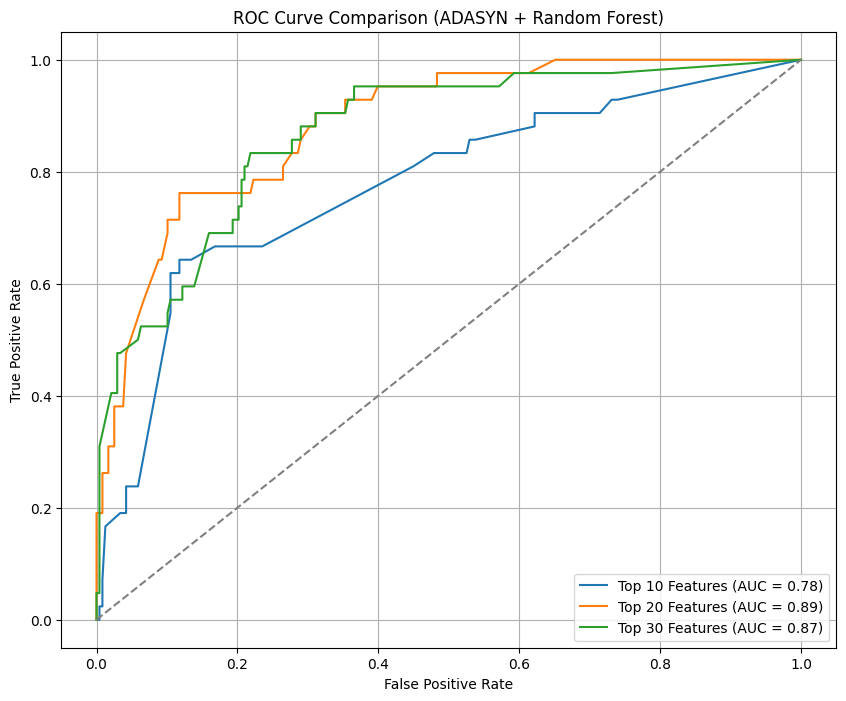

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve, auc
from imblearn.over_sampling import ADASYN  # <--- ADASYN oversampler

# List of files and labels
files = [
    ('/content/Atom2d2_Trainset_top10.csv', 'Top 10 Features'),
    ('/content/Atom2d2_Trainset_top20.csv', 'Top 20 Features'),
    ('/content/Atom2d2_Trainset_top30.csv', 'Top 30 Features')
]

plt.figure(figsize=(10, 8))  # For ROC plot

# Iterate over each dataset
for filepath, label in files:
    # Load and prepare data
    df = pd.read_csv(filepath)
    df = df.drop('Unnamed: 0', axis=1, errors='ignore')

    X = df.drop([" BioactivityClass"], axis=1)
    Y = df[" BioactivityClass"]

    # Train-test split
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=Y, random_state=42)

    # Apply ADASYN oversampling on training data only
    adasyn = ADASYN(random_state=42)
    X_train_resampled, Y_train_resampled = adasyn.fit_resample(X_train, Y_train)

    # Train Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train_resampled, Y_train_resampled)

    # Predictions
    y_pred = rf.predict(X_test)
    y_pred_proba = rf.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(Y_test, y_pred)
    auc_score_val = roc_auc_score(Y_test, y_pred_proba)

    print(f"\n=== {label} ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC: {auc_score_val:.4f}")
    print(f"Classification Report:\n{classification_report(Y_test, y_pred)}")

    # ROC curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')

# Plot ROC comparison
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (ADASYN + Random Forest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
